In [2]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)


# https://www.kaggle.com/datasets/ahmedmohamed2003/cafe-sales-dirty-data-for-cleaning-training
data = pd.read_csv('dirty_cafe_sales.csv')

data

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2,2.0,4.0,NaN,UNKNOWN,2023-08-30
9996,TXN_9659401,NaN,3,NaN,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3,NaN,3.0,Digital Wallet,NaN,2023-12-02


In [3]:
data.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 4.1 MB


<h3>memory usage is 4.1 MB. Can vastly decrease it by converting dtypes</h3>

In [4]:
data.columns = (
    data.columns
      .str.strip()
      .str.lower()
      .str.replace(' ', '_')
)


cols = ["total_spent", "quantity", "price_per_unit"]
data[cols] = data[cols].apply(pd.to_numeric, errors="coerce")


In [5]:
data['item'] = data['item'].astype('category')
data['location'] = data['location'].astype('category')
data['payment_method'] = data['payment_method'].astype('category')


# get rid of 'ERROR' and 'UNKNOWN' values

cols = ['item', 'payment_method', 'location']
data[cols] = data[cols].apply(lambda col: col.replace(['ERROR', 'UNKNOWN'], np.nan))

data['transaction_date'] = pd.to_datetime(
    data['transaction_date'],
    errors='coerce'
)
data.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_id    10000 non-null  object        
 1   item              9031 non-null   category      
 2   quantity          9521 non-null   float64       
 3   price_per_unit    9467 non-null   float64       
 4   total_spent       9498 non-null   float64       
 5   payment_method    6822 non-null   category      
 6   location          6039 non-null   category      
 7   transaction_date  9540 non-null   datetime64[ns]
dtypes: category(3), datetime64[ns](1), float64(3), object(1)
memory usage: 929.1 KB


<h3>Memory usage shrunk from 4.1 MB down to 929.5 KB (~78% decrease)<h3>

In [6]:
prices = {
    "Coffee": 2,
    "Tea": 1.5,
    "Sandwich": 4,
    "Salad": 5,
    "Cake": 3,
    "Cookie": 1,
    "Smoothie": 4,
    "Juice": 3
}

price_to_items = {}
for item, price in prices.items():
    price_to_items.setdefault(price, []).append(item)


<h2>Cleaning Missing Data</h2>
Can fill in missing data using other columns. For example, total_spent equals quantity * price_per_unit


Can also fill in price_per_unit from the item

In [7]:

# filling in price_per_unit using total_spent / quantity
missing_prices = (
    data["price_per_unit"].isnull()
    & data["total_spent"].notnull()
    & data["quantity"].notnull()
    & (data["quantity"] != 0)
)

data.loc[missing_prices, "price_per_unit"] = (
    data.loc[missing_prices, "total_spent"] / data.loc[missing_prices, "quantity"]
)


In [8]:
# filling in price_per_unit using item
mask = data["price_per_unit"].isnull() & data["item"].isin(prices)
data.loc[mask, "price_per_unit"] = data.loc[mask, "item"].map(prices)


In [9]:
# fill in total_spent using quantity * price_per_unit
mask = (
    data["total_spent"].isnull()
    & data["price_per_unit"].notnull()
    & data["quantity"].notnull()
)

data.loc[mask, "total_spent"] = (
    data.loc[mask, "price_per_unit"] * data.loc[mask, "quantity"]
)


In [10]:
# fill in quantity using total_spent / price_per_unit

mask = (
    data["quantity"].isnull()
    & data["total_spent"].notnull()
    & data["price_per_unit"].notnull()
    & (data["price_per_unit"] != 0)
)

data.loc[mask, "quantity"] = (
    data.loc[mask, "total_spent"] / data.loc[mask, "price_per_unit"]
)


In [11]:
"""
fill in item using price_per_unit. since some items have same prices as other items,
only fill in item for items with a unique price. 
They are Cookie, Tea, Coffee and Salad
"""
unique_price_map = {
    price: items[0]
    for price, items in price_to_items.items()
    if len(items) == 1
}

mask = data["item"].isnull() & data["price_per_unit"].isin(unique_price_map)
data.loc[mask, "item"] = data.loc[mask, "price_per_unit"].map(unique_price_map)


In [12]:
data.query("quantity.isnull() or price_per_unit.isnull() or total_spent.isnull()").sample(5)

,transaction_id,item,quantity,price_per_unit,total_spent,payment_method,location,transaction_date
5841,TXN_5884081,Cookie,NaN,1.0,NaN,Digital Wallet,In-store,2023-07-05
8574,TXN_2546684,Juice,NaN,3.0,NaN,Digital Wallet,Takeaway,2023-04-08
3779,TXN_7376255,NaN,NaN,NaN,25.0,NaN,In-store,2023-05-27
278,TXN_3229409,Juice,NaN,3.0,NaN,Cash,Takeaway,2023-04-15
9590,TXN_9924732,Sandwich,NaN,4.0,NaN,Credit Card,In-store,2023-01-18


Some missing values remain. For example:

Item - If the price_per_unit could refer to more than one item (eg. Cake and Juice are both $3), then leave as NaN

Quantity, price_per_unit, total_spent - can fill these 3 in if I have 2/3 of them. But if I only have 1, can't fill in

For example, transaction TXN_3251829 is Tea with correct price of $1.5, but has NaN for quantity and total_spent 

I can't fill in those values because I don't have enough information.

In [13]:
data.isnull().sum()

transaction_id         0
item                 480
quantity              23
price_per_unit         6
total_spent           23
payment_method      3178
location            3961
transaction_date     460
dtype: int64

In [14]:
data.query("item.isnull()") # item column still has null values because the price_per_unit can refer to more than 1 possible item

,transaction_id,item,quantity,price_per_unit,total_spent,payment_method,location,transaction_date
6,TXN_4433211,NaN,3.0,3.0,9.0,NaN,Takeaway,2023-10-06
8,TXN_4717867,NaN,5.0,3.0,15.0,NaN,Takeaway,2023-07-28
36,TXN_6855453,NaN,4.0,3.0,12.0,NaN,In-store,2023-07-17
61,TXN_8051289,NaN,1.0,3.0,3.0,NaN,In-store,2023-10-09
69,TXN_8471743,NaN,5.0,3.0,15.0,Digital Wallet,In-store,2023-04-06
...,...,...,...,...,...,...,...,...
9910,TXN_2338617,NaN,2.0,3.0,6.0,Digital Wallet,NaN,2023-01-12
9918,TXN_2292088,NaN,1.0,4.0,4.0,Digital Wallet,Takeaway,2023-03-04
9946,TXN_8807600,NaN,1.0,4.0,4.0,Cash,Takeaway,2023-09-24
9981,TXN_4583012,NaN,5.0,4.0,20.0,Digital Wallet,NaN,2023-02-27


transaction_id's aren't in any order. their dates are all over the place. can't ffill or bfill the dates

# Plotting
For Time Series analysis, can plot items or total_spent by month or day of week


In [15]:
data['day_of_week'] = data['transaction_date'].dt.day_name()
data['month'] = data['transaction_date'].dt.month_name()

earliest_date = data['transaction_date'].min()
latest_date = data['transaction_date'].max()
print("Earliest date is ", earliest_date)
print("Latest date is ", latest_date)
data

Earliest date is  2023-01-01 00:00:00
Latest date is  2023-12-31 00:00:00


,transaction_id,item,quantity,price_per_unit,total_spent,payment_method,location,transaction_date,day_of_week,month
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08,Friday,September
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16,Tuesday,May
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-store,2023-07-19,Wednesday,July
3,TXN_7034554,Salad,2.0,5.0,10.0,NaN,NaN,2023-04-27,Thursday,April
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11,Sunday,June
...,...,...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2.0,2.0,4.0,NaN,NaN,2023-08-30,Wednesday,August
9996,TXN_9659401,Cookie,3.0,1.0,3.0,Digital Wallet,NaN,2023-06-02,Friday,June
9997,TXN_5255387,Coffee,4.0,2.0,8.0,Digital Wallet,NaN,2023-03-02,Thursday,March
9998,TXN_7695629,Cookie,3.0,1.0,3.0,Digital Wallet,NaN,2023-12-02,Saturday,December


The data is just for the year 2023, starting at 01/01 until 12/31

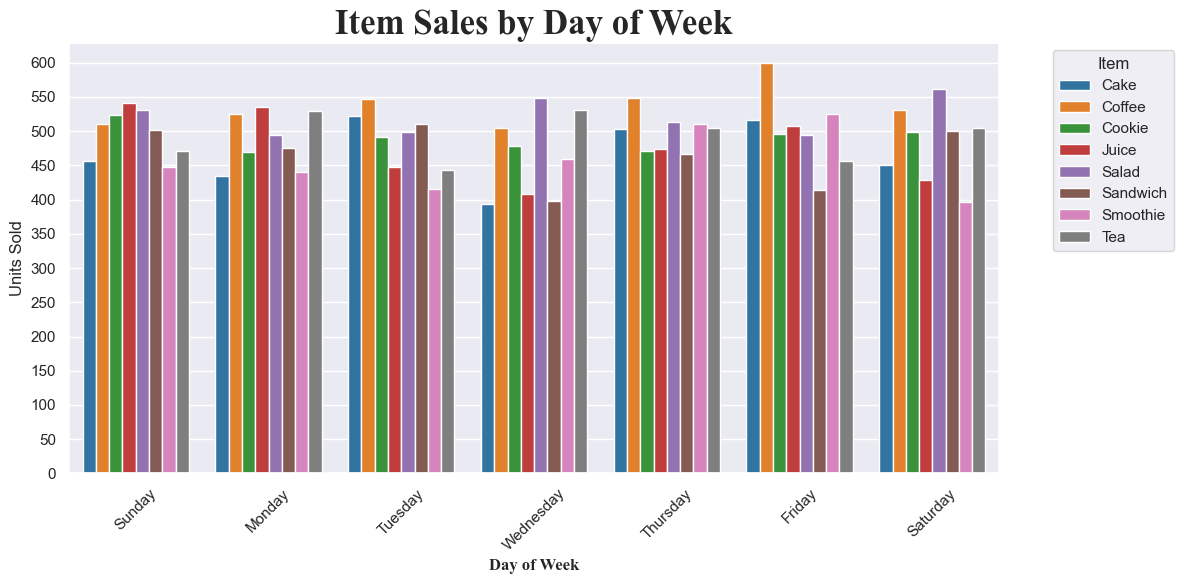

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="darkgrid")

order = ["Sunday", "Monday", "Tuesday", "Wednesday",
         "Thursday", "Friday", "Saturday"]
data["day_of_week"] = pd.Categorical(data["day_of_week"], categories=order, ordered=True)

sales = (
    data.groupby(["day_of_week", "item"])["quantity"]
    .sum()
    .reset_index()
)

# Create the bar plot
plt.figure(figsize=(12,6))
sns.barplot(
    data=sales,
    x="day_of_week",
    y="quantity",
    hue="item",
    palette="tab10"  
)

plt.xlabel("Day of Week", family='Times New Roman', fontweight='bold')
plt.ylabel("Units Sold")
plt.title("Item Sales by Day of Week", fontsize=25, family='Times New Roman', fontweight='bold')
plt.xticks(rotation=45)
plt.yticks(range(0, 601, 50))
plt.legend(title="Item", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


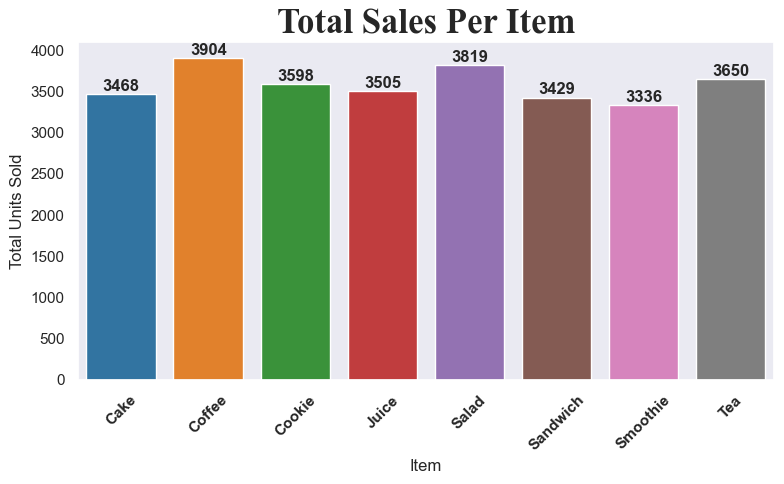

In [ ]:
sns.set_theme(style="dark")


# get total quantity sold per item
total_per_item = data.groupby("item")["quantity"].sum().reset_index()
total_per_item = total_per_item.sort_values("quantity", ascending=False)


plt.figure(figsize=(8,5))
ax = sns.barplot(
    data=total_per_item,
    x="item",
    y="quantity",
    palette="tab10"
)

# add numbers on top of bars
for p in ax.patches:
    height = p.get_height()
    ax.text(
        x=p.get_x() + p.get_width()/2,
        y=height + 1,   
        s=int(height),
        ha='center',
        va='bottom',
        fontweight='bold'
    )

plt.xlabel("Item")
plt.ylabel("Total Units Sold")
plt.title("Total Sales Per Item", fontsize=25, family='Times New Roman', fontweight='bold')
plt.xticks(rotation=45, fontweight='bold')
plt.tight_layout()
plt.show()


Since salad costs the most ($5), it brings in the most money too. Over 2023, it brought in 3819 * 5 = $19095

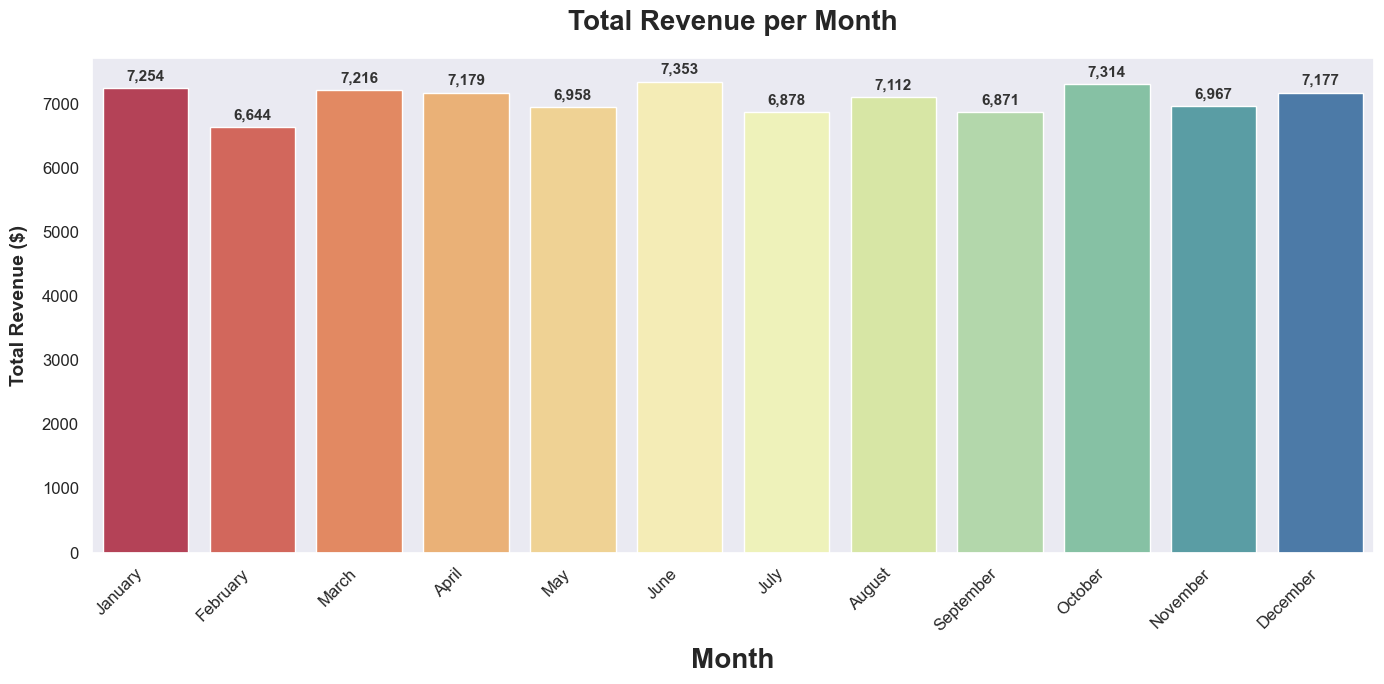

In [20]:

month_order = ["January", "February", "March", "April", "May", "June",
               "July", "August", "September", "October", "November", "December"]

data["month"] = pd.Categorical(data["month"], categories=month_order, ordered=True)

# aggregate total revenue per month
monthly_total = data.groupby("month")["total_spent"].sum().reset_index()

plt.figure(figsize=(14,7))
ax = sns.barplot(
    data=monthly_total,
    x="month",
    y="total_spent",
    palette="Spectral"
)

# annotate total revenue on top of each bar
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f'{height:,.0f}',  # comma for thousands
        (p.get_x() + p.get_width() / 2, height + max(monthly_total["total_spent"])*0.01),
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold',
        color="#333333"
    )

ax.set_title("Total Revenue per Month", fontsize=20, fontweight='bold', pad=20)
ax.set_xlabel("Month", fontsize=20, labelpad=10, fontweight='bold')
ax.set_ylabel("Total Revenue ($)", fontsize=14, labelpad=10, fontweight='bold')

ax.set_xticklabels(month_order, rotation=45, ha='right', fontsize=12)
ax.tick_params(axis='y', labelsize=12)

plt.tight_layout()
plt.show()
